In [ ]:
from cst_utils import set_seeds
from forecasting_models._chronos import Chronos
import numpy as np

# Manual assessment for Chronos deterministic behavior with random states

In [2]:
set_seeds()

In [ ]:
window = 28
context = 14

chronos_model = Chronos(window=window, context=context, max_context=512)

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
train_ts = np.sin(np.linspace(0, 2 * np.pi, 360))
test_ts = np.zeros(40)  

In [5]:
train_ts.shape

(360,)

In [6]:
predictions = []
for _ in range(10):
    preds = chronos_model.predict(train_ts, test_ts)
    predictions.append(preds)

2026-01-11 15:24:47,699 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:24:54,593 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:01,297 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:07,973 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:14,659 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:21,351 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:28,020 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:34,688 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:41,355 - INFO - Chronos contexts shape (13, 360)
2026-01-11 15:25:48,035 - INFO - Chronos contexts shape (13, 360)


In [8]:
predictions[0].shape

(13, 14)

All predictions are identical across 10 runs.
Prediction shape: (13, 14)


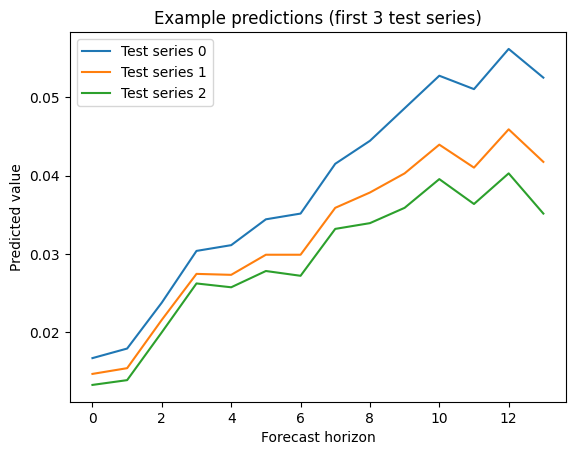

In [10]:
import matplotlib.pyplot as plt

# ---- determinism check ----
reference = predictions[0]
for i, preds in enumerate(predictions[1:], start=1):
    assert np.array_equal(reference, preds), f"Prediction mismatch at run {i}"

print("All predictions are identical across 10 runs.")
print("Prediction shape:", reference.shape)

# ---- visualization ----
plt.figure()
for i in range(3):  # visualize first 3 rows
    plt.plot(reference[i], label=f"Test series {i}")

plt.xlabel("Forecast horizon")
plt.ylabel("Predicted value")
plt.title("Example predictions (first 3 test series)")
plt.legend()
plt.show()

In [13]:
predictions[0][0], predictions[1][0]

(array([0.01672363, 0.01794434, 0.02380371, 0.03039551, 0.03112793,
        0.03442383, 0.03515625, 0.04150391, 0.04443359, 0.04858398,
        0.05273438, 0.05102539, 0.05615234, 0.05249023], dtype=float32),
 array([0.01672363, 0.01794434, 0.02380371, 0.03039551, 0.03112793,
        0.03442383, 0.03515625, 0.04150391, 0.04443359, 0.04858398,
        0.05273438, 0.05102539, 0.05615234, 0.05249023], dtype=float32))